# Minería de Datos y Modelización Predictiva
## Actividad de ACP y Cluster — Dataset Penguins

**Autor:** Carlos San Román Cazorla 

**Máster en Big Data, Data Science & Inteligencia Artificial — Universidad Complutense de Madrid**

---

El conjunto de datos `penguins` contiene información sobre tres especies de pingüinos (*Adelie*, *Chinstrap* y *Gentoo*) recogidas en tres islas (*Biscoe*, *Dream* y *Torgersen*). Las variables numéricas disponibles son:

- **bill_length_mm**: longitud del pico (mm)
- **bill_depth_mm**: profundidad del pico (mm)
- **flipper_length_mm**: longitud de la aleta (mm)
- **body_mass_g**: masa corporal (g)

El objetivo es, en primer lugar, aplicar un **Análisis de Componentes Principales (ACP)** para reducir la dimensionalidad y explorar las relaciones entre variables y especies. Posteriormente, se realizará un **Análisis Cluster** (jerárquico y no jerárquico) para identificar agrupaciones naturales en los datos.

## Preparación del Entorno

In [1]:
# Importamos todas las librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

from scipy.spatial import distance
from scipy.spatial.distance import pdist, squareform
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## Lectura y Preparación de los Datos

In [2]:
# Cargamos el dataset desde el archivo Excel
penguins = pd.read_excel(r'C:\Users\carlo\OneDrive\Desktop\MASTER_BIG_DATA_DATA_SCIENCE_IA\MASTER_BIG_DATA_DATA_SCIENCE_IA\PCA_CLUSTER\Datos\penguins.xlsx')
print(f'Dimensiones del dataset: {penguins.shape}')
penguins.head(10)

Dimensiones del dataset: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,Male
1,Adelie,Torgersen,39.5,17.4,186,3800,Female
2,Adelie,Torgersen,40.3,18.0,195,3250,Female
3,Adelie,Torgersen,36.7,19.3,193,3450,Female
4,Adelie,Torgersen,39.3,20.6,190,3650,Male
5,Adelie,Torgersen,38.9,17.8,181,3625,Female
6,Adelie,Torgersen,39.2,19.6,195,4675,Male
7,Adelie,Torgersen,41.1,17.6,182,3200,Female
8,Adelie,Torgersen,38.6,21.2,191,3800,Male
9,Adelie,Torgersen,34.6,21.1,198,4400,Male


In [3]:
# Guardamos las variables categóricas como variables suplementarias
species = penguins['species'].copy()
island  = penguins['island'].copy()
sex     = penguins['sex'].copy()

# Seleccionamos únicamente las variables numéricas para el ACP
variables = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
datos = penguins[variables].copy()

print(f'Variables numéricas seleccionadas: {variables}')
print(f'Número de observaciones antes de eliminar NaN: {len(datos)}')

# Eliminamos filas con valores perdidos
mask_validos = datos.notna().all(axis=1)
datos    = datos[mask_validos].reset_index(drop=True)
species  = species[mask_validos].reset_index(drop=True)
island   = island[mask_validos].reset_index(drop=True)
sex      = sex[mask_validos].reset_index(drop=True)

print(f'Número de observaciones tras eliminar NaN: {len(datos)}')
datos.head()

Variables numéricas seleccionadas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Número de observaciones antes de eliminar NaN: 333
Número de observaciones tras eliminar NaN: 333


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181,3750
1,39.5,17.4,186,3800
2,40.3,18.0,195,3250
3,36.7,19.3,193,3450
4,39.3,20.6,190,3650


---
# PARTE I: ANÁLISIS DE COMPONENTES PRINCIPALES (ACP)

## 1. Análisis Descriptivo y Matriz de Correlaciones

Antes de empezar con el PCA es conveniente realizar un análisis descriptivo de las variables, para observar si hay alguna anomalía en los datos, como datos fuera de rango, atípicos o perdidos.

In [4]:
# Estadísticos descriptivos de las variables numéricas
estadisticos = pd.DataFrame({
    'Mínimo'              : datos[variables].min(),
    'Percentil 25'        : datos[variables].quantile(0.25),
    'Mediana'             : datos[variables].median(),
    'Percentil 75'        : datos[variables].quantile(0.75),
    'Media'               : datos[variables].mean(),
    'Máximo'              : datos[variables].max(),
    'Desviación Estándar' : datos[variables].std(),
    'Varianza'            : datos[variables].var(),
    'Datos Perdidos'      : datos[variables].isna().sum()
})
estadisticos.round()

,Mínimo,Percentil 25,Mediana,Percentil 75,Media,Máximo,Desviación Estándar,Varianza,Datos Perdidos
bill_length_mm,32.0,40.0,44.0,49.0,44.0,60.0,5.0,30.0,0
bill_depth_mm,13.0,16.0,17.0,19.0,17.0,22.0,2.0,4.0,0
flipper_length_mm,172.0,190.0,197.0,213.0,201.0,231.0,14.0,196.0,0
body_mass_g,2700.0,3550.0,4050.0,4775.0,4207.0,6300.0,805.0,648372.0,0


> **Comentario:** Las variables presentan escalas muy diferentes: `body_mass_g` se mide en gramos (rango ~2700–6300) mientras que `bill_depth_mm` está en milímetros (rango ~13–21). Esta diferencia de escala hace imprescindible la estandarización antes del ACP. No se detectan valores perdidos ni valores fuera de rango.

También es importante analizar las relaciones entre las variables, ya que si mostrasen fuerte independencia, no tendría sentido realizar un PCA. Para ello calculamos las matrices de covarianzas y correlaciones.

In [5]:
# Calculamos la matriz de correlaciones de Pearson
C = datos.cov()
print('Matriz de Covarianzas:')
C

Matriz de Covarianzas:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,29.906333,-2.462091,50.058195,2595.623304
bill_depth_mm,-2.462091,3.877888,-15.947248,-748.456122
flipper_length_mm,50.058195,-15.947248,196.441677,9852.191649
body_mass_g,2595.623304,-748.456122,9852.191649,648372.487699


In [6]:
# Calculamos la matriz de correlaciones de Pearson
R = datos.corr()
print('Matriz de Correlaciones:')
R

Matriz de Correlaciones:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


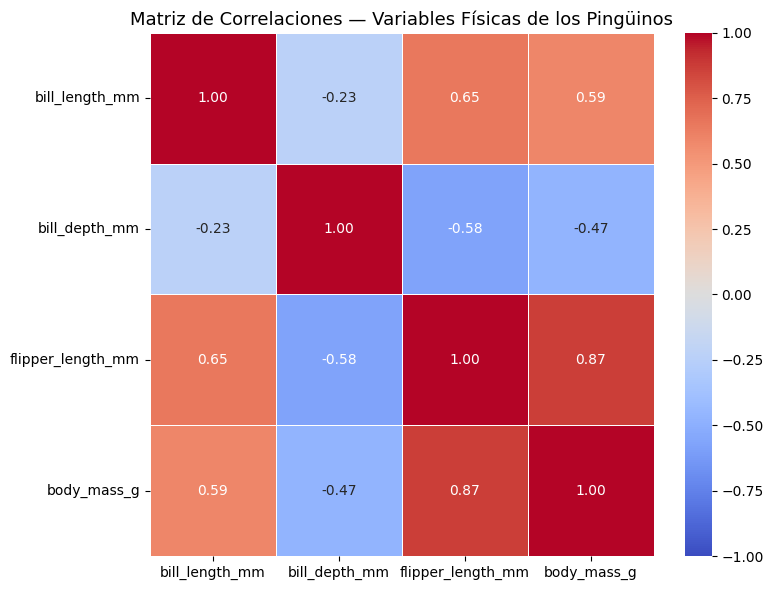

In [7]:
# Representación gráfica de la matriz de correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(R, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Matriz de Correlaciones — Variables Físicas de los Pingüinos', fontsize=13)
plt.tight_layout()
plt.show()

> **Interpretación de las correlaciones:**
> - `flipper_length_mm` y `body_mass_g` presentan la correlación positiva más alta (~0.87), lo que indica que los pingüinos con aletas más largas son también más pesados.
> - `bill_length_mm` correlaciona positivamente con `flipper_length_mm` (0.65) y con `body_mass_g` (0.59).
> - `bill_depth_mm` muestra **correlación negativa** con el resto de variables (especialmente con `flipper_length_mm` -0.58 y `body_mass_g` -0.47), lo que sugiere que la profundidad del pico sigue un patrón distinto, relacionado con diferencias entre especies.
> - La existencia de correlaciones significativas justifica la aplicación del ACP.

## 2. ACP Exploratorio: Selección del Número de Componentes (máximo 4)

Ahora, estamos en disposición de empezar el PCA. Para ello, lo primero, estandarizamos los datos, que pese a estar en la misma escala las variables que miden la misma magnitud, tenemos grandes diferencias en valores entre milímetros y gramos, luego es aconsejable.

$$Z_{ij} = \frac{X_{ij} - \bar{X}_j}{s_j}, i \in n, j \in p$$

In [8]:
# Estandarizamos los datos (media=0, desviación=1)
datos_estandarizados = pd.DataFrame(
    StandardScaler().fit_transform(datos),
    columns=[f'{v}_z' for v in variables],
    index=datos.index
)
datos_estandarizados.head()

,bill_length_mm_z,bill_depth_mm_z,flipper_length_mm_z,body_mass_g_z
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
3,-1.335566,1.085877,-0.569284,-0.941606
4,-0.859415,1.747026,-0.783651,-0.692852


Una vez hemos estandarizado los datos, calculamos las componentes principales, establenciendo el máximo de componentes para tener la total explicabilidad de la varianza. A continuación, procedemos a calcular los autovalores asociados a las componentes principales (valores $\lambda$ que resuelven la ecuación $\text{det}(\Sigma - \lambda I) = 0$).

In [9]:
# ACP completo con las 4 componentes posibles
pca_completo = PCA(n_components=4)
fit_completo  = pca_completo.fit(datos_estandarizados)

# Autovalores y varianza explicada
autovalores_completo = fit_completo.explained_variance_
var_explicada        = fit_completo.explained_variance_ratio_ * 100
var_acumulada        = np.cumsum(var_explicada)

tabla_autovalores = pd.DataFrame({
    'Autovalor (λ)'          : autovalores_completo,
    'Variabilidad Explicada (%)' : var_explicada,
    'Variabilidad Acumulada (%)' : var_acumulada
}, index=[f'Componente {i}' for i in range(1, 5)])

tabla_autovalores.round(4)

,Autovalor (λ),Variabilidad Explicada (%),Variabilidad Acumulada (%)
Componente 1,2.7536,68.6339,68.6339
Componente 2,0.7805,19.4529,88.0868
Componente 3,0.3698,9.2161,97.3029
Componente 4,0.1082,2.6971,100.0000


Hemos desarrollado el PCA completo, con todas las posibles Componentes, no obstante, como sabemos, esto no es lo ideal, pues nuestro objetivo es reducir la dimensionalidad. Para ello debemos decidir con cuantas CP nos vamos a quedar. Para ello, nos fijamos en la varianza explicada / varianza explicada acumulada y el gráfico del "Codo".

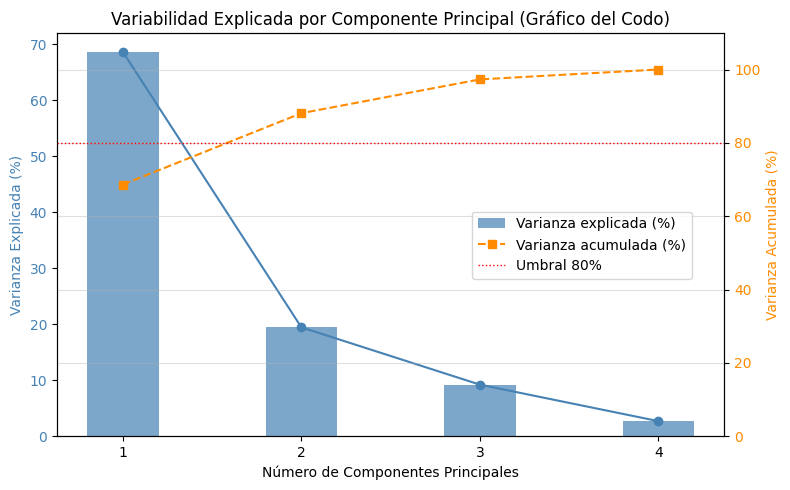

In [10]:
# Gráfico del 'codo' — variabilidad explicada por componente
def plot_varianza_explicada(var_explicada, var_acumulada, n_components):
    num_comp = np.arange(1, n_components + 1)
    fig, ax1 = plt.subplots(figsize=(8, 5))

    color1 = 'steelblue'
    ax1.bar(num_comp, var_explicada, width=0.4, align='center',
            alpha=0.7, color=color1, label='Varianza explicada (%)')
    ax1.plot(num_comp, var_explicada, marker='o', color=color1)
    ax1.set_xlabel('Número de Componentes Principales')
    ax1.set_ylabel('Varianza Explicada (%)', color=color1)
    ax1.set_xticks(num_comp)
    ax1.tick_params(axis='y', labelcolor=color1)

    ax2 = ax1.twinx()
    ax2.plot(num_comp, var_acumulada, marker='s', linestyle='--',
             color='darkorange', label='Varianza acumulada (%)')
    ax2.axhline(80, color='red', linestyle=':', linewidth=1, label='Umbral 80%')
    ax2.set_ylabel('Varianza Acumulada (%)', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.set_ylim(0, 110)

    plt.title('Variabilidad Explicada por Componente Principal (Gráfico del Codo)')
    fig.legend(loc='center right', bbox_to_anchor=(0.88, 0.5))
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_varianza_explicada(var_explicada, var_acumulada, 4)

> **Decisión sobre el número de componentes:**  
> Observando la tabla de autovalores y el gráfico del codo:
> - La **Componente 1** explica el ~69% de la variabilidad total.
> - La **Componente 2** añade otro ~19%, acumulando ~88%.
> - A partir de la tercera componente, la ganancia marginal es muy pequeña (<9% adicional).
>
> El criterio del codo indica claramente un quiebre entre la 2.ª y la 3.ª componente. Además, la regla de Kaiser (retener componentes con λ > 1) también señala **2 componentes** (λ₁ ≈ 2.77 > 1, λ₂ ≈ 0.77 < 1 aproximadamente).
>
> Con **2 componentes principales** se explica en torno al **88% de la variabilidad total**, lo que es muy satisfactorio. Retenemos por tanto **k = 2**.

## 3. ACP con 2 Componentes Principales

Una vez hemos decidido quedarnos con las dos primeras componentes, procedemos a calcularlas. Para ello necesitamos conocer la matriz de transformación formada por los autovectores o vectores propios asociados a los autovalores seleccionados. Repetimos el proceso seleccionando unicamente dos componentes principales

In [11]:
# ACP definitivo con k=2 componentes
pca = PCA(n_components=2)
fit = pca.fit(datos_estandarizados)

autovalores = fit.explained_variance_
print(f'Autovalores: CP1 = {autovalores[0]:.4f} | CP2 = {autovalores[1]:.4f}')
print(f'Varianza explicada: CP1 = {fit.explained_variance_ratio_[0]*100:.2f}% | CP2 = {fit.explained_variance_ratio_[1]*100:.2f}%')
print(f'Varianza acumulada (2 CP): {sum(fit.explained_variance_ratio_)*100:.2f}%')

Autovalores: CP1 = 2.7536 | CP2 = 0.7805
Varianza explicada: CP1 = 68.63% | CP2 = 19.45%
Varianza acumulada (2 CP): 88.09%


In [12]:
# Autovectores (vectores propios) — Matriz de transformación W
autovectores = pd.DataFrame(
    fit.components_.T,
    columns=[f'Autovector {i}' for i in range(1, fit.n_components_ + 1)],
    index=[f'{v}_z' for v in variables]
)
print('Matriz de Transformación W (autovectores):')
autovectores.round(4)

Matriz de Transformación W (autovectores):


,Autovector 1,Autovector 2
bill_length_mm_z,0.4538,0.6002
bill_depth_mm_z,-0.3990,0.7962
flipper_length_mm_z,0.5768,0.0058
body_mass_g_z,0.5497,0.0765


Una vez tenemos nuestros datos tipificados $Z$ y nuestra matriz de transformación $W$ procedemos a calcular las componentes principales $CP$ tales que $CP = ZW$, es decir, 

$$CP_1 = 0.4538 \cdot \text{bill\_length\_mm}_z - 0.399 \cdot \text{bill\_depth\_mm}_z + 0.5768 \cdot \text{flipper\_length\_mm}_z + 0.5497 \cdot \text{body\_mass\_g}_z$$

$$CP_2 = 0.6002 \cdot \text{bill\_length\_mm}_z + 0.7962 \cdot \text{bill\_depth\_mm}_z + 0.0058 \cdot \text{flipper\_length\_mm}_z + 0.0765 \cdot \text{body\_mass\_g}_z$$

In [13]:
# Coordenadas de las observaciones en las nuevas componentes
resultados_pca = pd.DataFrame(
    fit.transform(datos_estandarizados),
    columns=[f'Componente {i}' for i in range(1, fit.n_components_ + 1)],
    index=datos_estandarizados.index
)
print('Primeras 5 observaciones en el nuevo espacio ACP:')
resultados_pca.head()

Primeras 5 observaciones en el nuevo espacio ACP:


,Componente 1,Componente 2
0,-1.853593,0.032069
1,-1.316254,-0.443527
2,-1.376605,-0.161230
3,-1.885288,-0.012351
4,-1.919981,0.817598


### 3a. Cálculo numérico de la primera observación en la primera componente

La primera componente principal se calcula como combinación lineal de las variables estandarizadas:  
$$\text{CP}_1 = e_{11} \cdot Z_{\text{bill\_length}} + e_{21} \cdot Z_{\text{bill\_depth}} + e_{31} \cdot Z_{\text{flipper\_length}} + e_{41} \cdot Z_{\text{body\_mass}}$$
donde $e_{j1}$ son los coeficientes del primer autovector.

In [14]:
# Valores estandarizados de la primera observación
obs1_z = datos_estandarizados.iloc[0]
print('Valores estandarizados de la primera observación:')
for var_z, val in obs1_z.items():
    print(f'  {var_z} = {val:.6f}')

# Coeficientes del primer autovector
e1 = autovectores['Autovector 1']
print('\nCoeficientes del primer autovector (e_j1):')
for var_z, coef in e1.items():
    print(f'  {var_z}: e_j1 = {coef:.6f}')

# Cálculo paso a paso
print('\nCálculo paso a paso de CP1 para la observación 1:')
cp1_manual = 0
for var_z in datos_estandarizados.columns:
    termino = obs1_z[var_z] * e1[var_z]
    cp1_manual += termino
    print(f'  ({obs1_z[var_z]:.6f}) × ({e1[var_z]:.6f}) = {termino:.6f}')

print(f'\nCP1 (calculado manualmente) = {cp1_manual:.6f}')
print(f'CP1 (calculado por sklearn)  = {resultados_pca.iloc[0, 0]:.6f}')

Valores estandarizados de la primera observación:
  bill_length_mm_z = -0.896042
  bill_depth_mm_z = 0.780732
  flipper_length_mm_z = -1.426752
  body_mass_g_z = -0.568475

Coeficientes del primer autovector (e_j1):
  bill_length_mm_z: e_j1 = 0.453753
  bill_depth_mm_z: e_j1 = -0.399047
  flipper_length_mm_z: e_j1 = 0.576825
  body_mass_g_z: e_j1 = 0.549675

Cálculo paso a paso de CP1 para la observación 1:
  (-0.896042) × (0.453753) = -0.406582
  (0.780732) × (-0.399047) = -0.311549
  (-1.426752) × (0.576825) = -0.822986
  (-0.568475) × (0.549675) = -0.312476

CP1 (calculado manualmente) = -1.853593
CP1 (calculado por sklearn)  = -1.853593


### 3b. Gráficos de las variables en los planos de las componentes (Círculo de correlaciones)

In [15]:
# Calculamos las correlaciones entre variables originales y componentes principales
# Corr(CPi, Xj) = e_ij * sqrt(lambda_i) / s_j
# Como trabajamos con datos estandarizados, s_j = 1, por lo que:
# Corr(CPi, Xj) = e_ij * sqrt(lambda_i)

datos_z_cp = pd.concat([datos_estandarizados, resultados_pca], axis=1)
Correlaciones_var_comp = datos_z_cp.corr()
# Extraemos solo la submatriz variables x componentes
Correlaciones_var_comp = Correlaciones_var_comp.iloc[:fit.n_features_in_, fit.n_features_in_:]
Correlaciones_var_comp.columns = [f'Componente {i}' for i in range(1, fit.n_components_ + 1)]
print('Correlaciones entre variables y componentes principales:')
Correlaciones_var_comp

Correlaciones entre variables y componentes principales:


,Componente 1,Componente 2
bill_length_mm_z,0.751829,0.529438
bill_depth_mm_z,-0.661186,0.702309
flipper_length_mm_z,0.955748,0.005106
body_mass_g_z,0.910762,0.067449


Como podemos observar la primera componente principal $CP_1$ presenta prácticamente el total de la explicabilidad para las variables $flipper\_length\_mm_z$ y $body\_mass\_g_z$ al presentar una correlación de 0.9557 y 0.91 , respectivamente. Además, es interesante señalar que las variables $bill\_length\_mm_z$ y $bill\_depth\_mm_z$ están correlacionadas con ambas componentes, luego habrá influencia de ambas componentes en las dos variables, destacando la correlación negativa con $CP_1$.

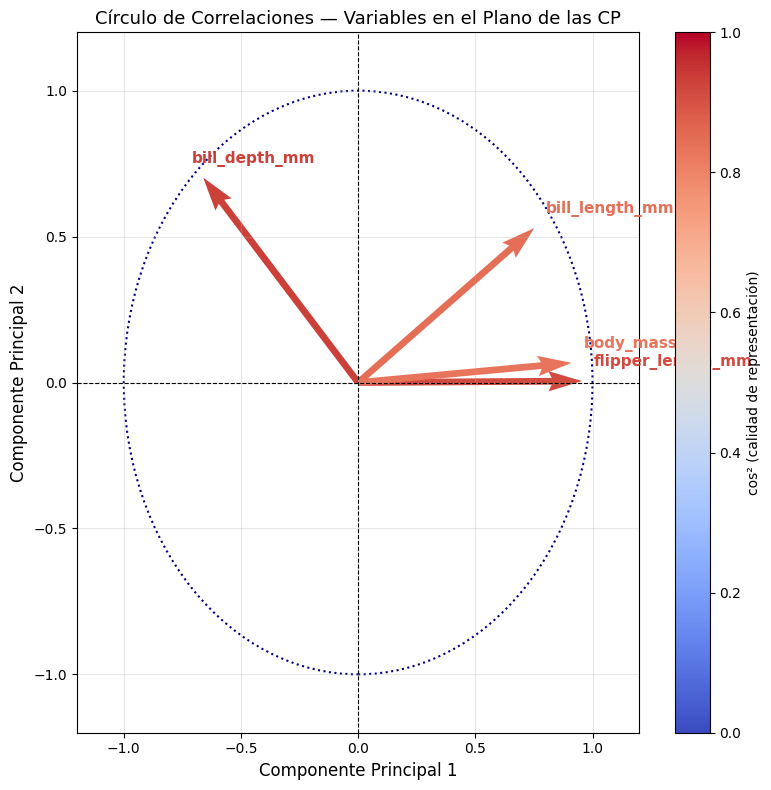

In [16]:
# Función para el círculo de correlaciones
def plot_circulo_correlaciones(correlaciones, variables_nombres):
    cmap = plt.get_cmap('coolwarm')
    n_cp = correlaciones.shape[1]

    for i in range(n_cp):
        for j in range(i + 1, n_cp):
            sum_cos2 = correlaciones.iloc[:, i]**2 + correlaciones.iloc[:, j]**2

            fig, ax = plt.subplots(figsize=(8, 8))
            circle = plt.Circle((0, 0), 1, fill=False, color='navy', linestyle='dotted', linewidth=1.5)
            ax.add_patch(circle)

            for k, var_name in enumerate(correlaciones.index):
                x = correlaciones.iloc[k, i]
                y = correlaciones.iloc[k, j]
                color = cmap(sum_cos2.iloc[k])
                ax.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1,
                          color=color, width=0.012)
                offset_x = 0.05 if x >= 0 else -0.05
                offset_y = 0.05 if y >= 0 else -0.08
                etiqueta = variables_nombres[k]
                ax.text(x + offset_x, y + offset_y, etiqueta,
                        color=color, fontsize=11, fontweight='bold')

            ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
            ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
            ax.set_xlabel(f'Componente Principal {i+1}', fontsize=12)
            ax.set_ylabel(f'Componente Principal {j+1}', fontsize=12)
            ax.set_xlim(-1.2, 1.2)
            ax.set_ylim(-1.2, 1.2)
            ax.set_title('Círculo de Correlaciones — Variables en el Plano de las CP', fontsize=13)

            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
            sm.set_array([])
            plt.colorbar(sm, ax=ax, label='cos² (calidad de representación)')
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

plot_circulo_correlaciones(Correlaciones_var_comp, variables)

> **Interpretación del círculo de correlaciones:**
> - **Componente Principal 1 (CP1):** Correlaciona fuertemente y de forma positiva con `bill_length_mm`, `flipper_length_mm` y `body_mass_g`. Las tres variables apuntan hacia el lado derecho del gráfico. Esta componente podría interpretarse como un **índice de tamaño general del pingüino**: valores altos en CP1 corresponden a individuos más grandes (mayor longitud de pico, aleta y masa). La especie *Gentoo*, de mayor tamaño, tenderá a destacar en esta componente.
> - **Componente Principal 2 (CP2):** Correlaciona fuertemente con `bill_depth_mm` (positiva). Esta variable apunta en sentido opuesto a las demás en CP2, mientras `bill_length_mm` apunta levemente hacia el eje negativo. Esta componente captura principalmente la **forma del pico** (profundidad vs. longitud), diferenciando entre especies con pico más profundo y corto (*Adelie*, *Chinstrap*) frente a los de pico largo y menos profundo (*Gentoo*).

### 3c. Gráfico de las observaciones en los nuevos ejes (por especie)

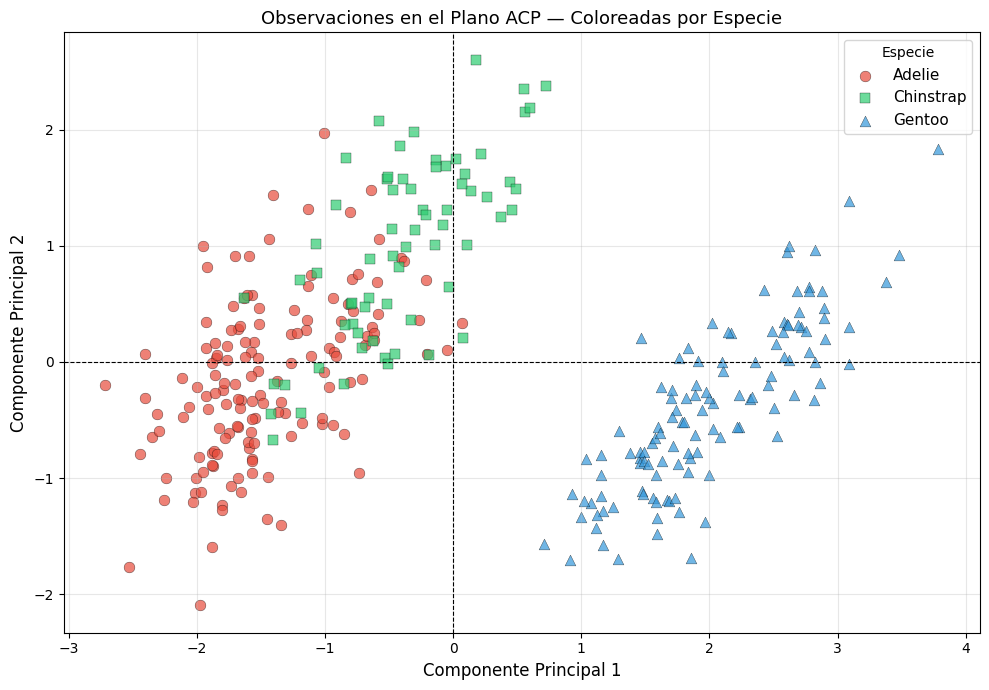

In [17]:
# Gráfico de dispersión de las observaciones coloreadas por especie
colores_especie = {'Adelie': '#E74C3C', 'Chinstrap': '#2ECC71', 'Gentoo': '#3498DB'}
marcadores_especie = {'Adelie': 'o', 'Chinstrap': 's', 'Gentoo': '^'}

fig, ax = plt.subplots(figsize=(10, 7))

for especie in species.unique():
    mask = (species == especie)
    ax.scatter(
        resultados_pca.loc[mask, 'Componente 1'],
        resultados_pca.loc[mask, 'Componente 2'],
        label=especie,
        color=colores_especie[especie],
        marker=marcadores_especie[especie],
        alpha=0.7, s=60, edgecolors='black', linewidths=0.3
    )

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Componente Principal 1', fontsize=12)
ax.set_ylabel('Componente Principal 2', fontsize=12)
ax.set_title('Observaciones en el Plano ACP — Coloreadas por Especie', fontsize=13)
ax.legend(title='Especie', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **Interpretación:**
> - **CP1 (tamaño general):** Los *Gentoo* (triángulos azules) se separan claramente hacia la derecha, indicando que son los pingüinos más grandes pero con una profundidad del pico más pequeño (coincidentes con la direccción del plano en sentido contrario a la variable bill\depth\_mm). *Adelie* y *Chinstrap* ocupan la zona izquierda, con tamaños similares (diferenciándose en que el *Adelie*, los círculos rojos, tienen el pico más corto).
> - **CP2 (forma del pico):** Los *Chinstrap* (cuadrados verdes) tienden a situarse en la parte superior, diferenciándose de los *Adelie* (círculos rojos) que se ubican más en la parte inferior-izquierda, mostrando una mayor profundidad del pico en los *Chinstrap* que en los *Adelie*. *Gentoo* se agrupa en la zona inferior-derecha, indicando que tienen un pico menos uniforme en cuanto a longitud..
> - En resumen: **CP1 distingue principalmente a Gentoo del resto; CP2 diferencia Chinstrap de Adelie**.

### 3d. Relación entre las Componentes Principales y las Variables: Cosenos al Cuadrado y Contribuciones

In [18]:
# --- Cos² (contribución de las CP a la variabilidad de cada variable) ---
cos2 = cos2 = Correlaciones_var_comp**2
cos2
cos2['Suma cos²'] = cos2.sum(axis=1)
print('Cosenos al Cuadrado (cos²) — Calidad de representación de cada variable:')
cos2.round(4)

Cosenos al Cuadrado (cos²) — Calidad de representación de cada variable:


,Componente 1,Componente 2,Suma cos²
bill_length_mm_z,0.5652,0.2803,0.8456
bill_depth_mm_z,0.4372,0.4932,0.9304
flipper_length_mm_z,0.9135,0.0000,0.9135
body_mass_g_z,0.8295,0.0045,0.8340


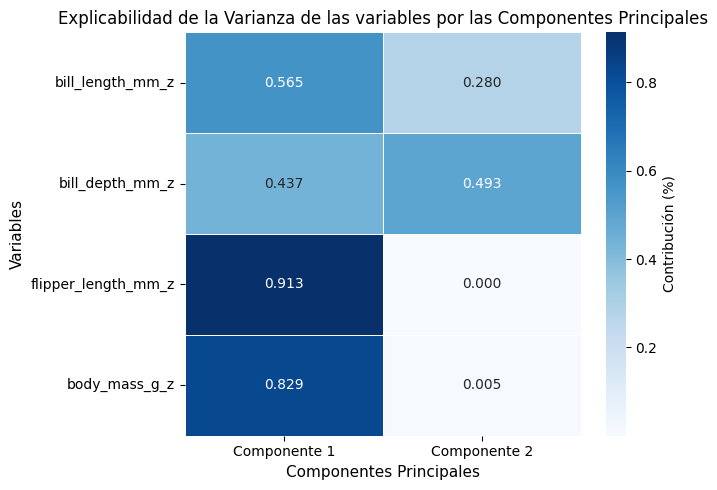

In [19]:
# Mapa de calor de contribuciones
plt.figure(figsize=(7, 5))
sns.heatmap(
    cos2[['Componente 1', 'Componente 2']], cmap='Blues', linewidths=0.5, annot=True, fmt='.3f',
    cbar_kws={'label': 'Contribución (%)'}
)
plt.xlabel('Componentes Principales', fontsize=11)
plt.ylabel('Variables', fontsize=11)
plt.title('Explicabilidad de la Varianza de las variables por las Componentes Principales', fontsize=12)
plt.tight_layout()
plt.show()

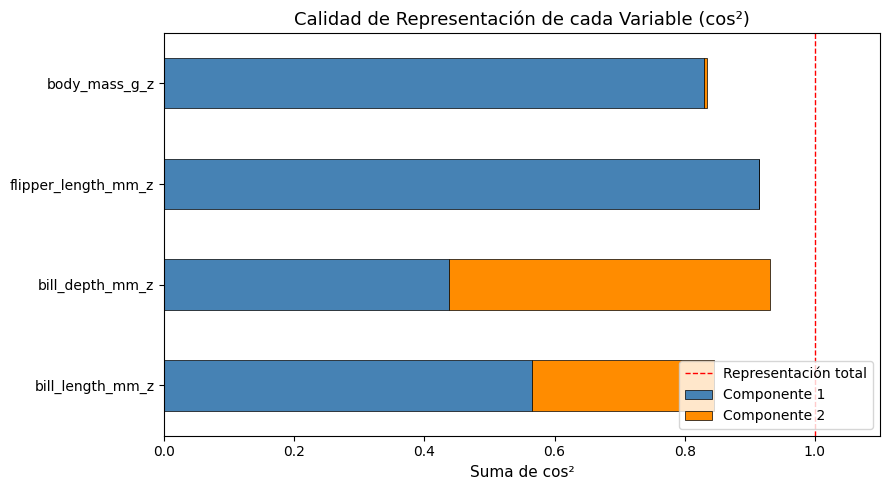

In [20]:
# Gráfico de barras apiladas de los cos²
cos2_plot = cos2[['Componente 1', 'Componente 2']]
colors = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(9, 5))
cos2_plot.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='Representación total')
ax.set_xlabel('Suma de cos²', fontsize=11)
ax.set_title('Calidad de Representación de cada Variable (cos²)', fontsize=13)
ax.legend(loc='lower right')
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.show()

In [21]:
# --- Contribuciones de cada variable a cada Componente Principal ---
def calcular_contribuciones(cos2_df, autovalores, n_components):
    cols_cp = [f'Componente {i+1}' for i in range(n_components)]
    cos2_cp = cos2_df[cols_cp]
    contribuciones = cos2_cp * np.sqrt(autovalores)
    sumas = contribuciones.sum(axis=0)
    contribuciones_prop = (contribuciones / sumas) * 100
    return contribuciones_prop

cos2_para_contrib = cos2[['Componente 1', 'Componente 2']].copy()
cos2_para_contrib.index = [f'{v}_z' for v in variables]

contrib_prop = calcular_contribuciones(cos2_para_contrib, autovalores, fit.n_components_)
print('Contribuciones Proporcionales (%) de cada variable a las Componentes Principales:')
contrib_prop.round(2)

Contribuciones Proporcionales (%) de cada variable a las Componentes Principales:


,Componente 1,Componente 2
bill_length_mm_z,20.59,36.02
bill_depth_mm_z,15.92,63.39
flipper_length_mm_z,33.27,0.00
body_mass_g_z,30.21,0.58


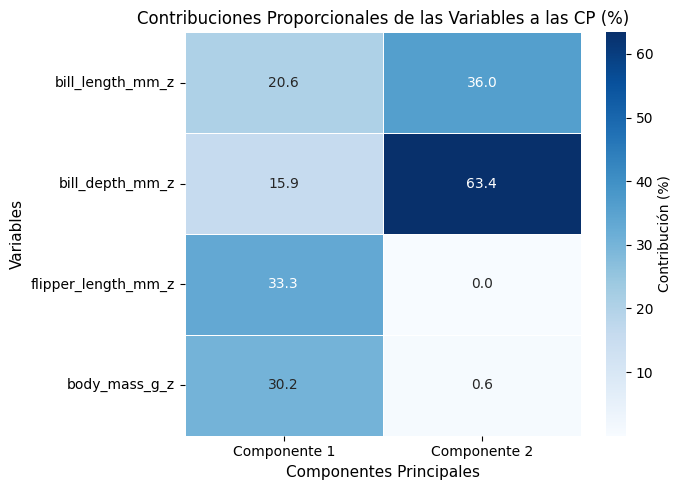

In [22]:
# Mapa de calor de contribuciones
plt.figure(figsize=(7, 5))
sns.heatmap(
    contrib_prop, cmap='Blues', linewidths=0.5, annot=True, fmt='.1f',
    cbar_kws={'label': 'Contribución (%)'}
)
plt.xlabel('Componentes Principales', fontsize=11)
plt.ylabel('Variables', fontsize=11)
plt.title('Contribuciones Proporcionales de las Variables a las CP (%)', fontsize=12)
plt.tight_layout()
plt.show()

> **Interpretación:**
> - **Cos²:** Todas las variables tienen una suma de cos² cercana a 1, lo que indica que están bien representadas por las dos componentes retenidas. `flipper_length_mm` y `body_mass_g` son las mejor representadas, mientras que `bill_depth_mm` tiene la representación más baja (aunque sigue siendo aceptable).
> - **Contribuciones a CP1:** `flipper_length_mm` y `body_mass_g` son las variables que más contribuyen a la primera componente, seguidas de `bill_length_mm`. `bill_depth_mm` apenas contribuye a CP1.
> - **Contribuciones a CP2:** `bill_depth_mm` es, con diferencia, la variable que más aporta a la segunda componente, confirmando que CP2 captura esencialmente la variabilidad en la profundidad del pico.

### 3e. Variables Suplementarias: Centroides de Especie e Isla en el Plano ACP

Por último vamos  vamos a considerar la posibilidad de añadir una nueva variable categórica al análisis. Como sabemos, las variables categóricas no pueden pertenecer al PCA, pero, ¿cómo se relacionaría con dicho analisis?

Cuando incorporamos una variable categórica a un PCA previamente realizado, estamos enriqueciendo nuestra comprensión de los datos al considerar la influencia de categorías adicionales en la estructura de los datos. En este contexto, representar los centroides de estas categorías en los nuevos ejes de las componentes principales se convierte en una estrategia esencial. Los centroides actúan como puntos de referencia que resumen la tendencia central de cada categoría en el espacio de las CP. Este enfoque nos permite visualizar cómo las distintas categorías se relacionan entre sí y con las CP, lo que puede revelar patrones y relaciones más sutiles en los datos que antes no eran evidentes. En esencia, al considerar variables categóricas y representar sus centroides en el PCA, estamos agregando una dimensión adicional a nuestra comprensión de la estructura subyacente de los datos.

In [23]:
# Unimos las componentes con las variables categóricas
datos_con_cp = pd.concat([resultados_pca, species.rename('species'), island.rename('island')], axis=1)

# Calculamos los centroides de cada especie en el espacio ACP
centroides_especie = datos_con_cp.groupby('species')[['Componente 1', 'Componente 2']].mean()
print('Centroides de cada especie:')
centroides_especie.round(4)

Centroides de cada especie:


,Componente 1,Componente 2
species,,
Adelie,-1.4597,-0.1415
Chinstrap,-0.3886,0.9934
Gentoo,2.0130,-0.3940


In [24]:
# Centroides de cada isla
centroides_isla = datos_con_cp.groupby('island')[['Componente 1', 'Componente 2']].mean()
print('Centroides de cada isla:')
centroides_isla.round(4)

Centroides de cada isla:


,Componente 1,Componente 2
island,,
Biscoe,1.0638,-0.3189
Dream,-0.8738,0.4513
Torgersen,-1.4025,-0.0751


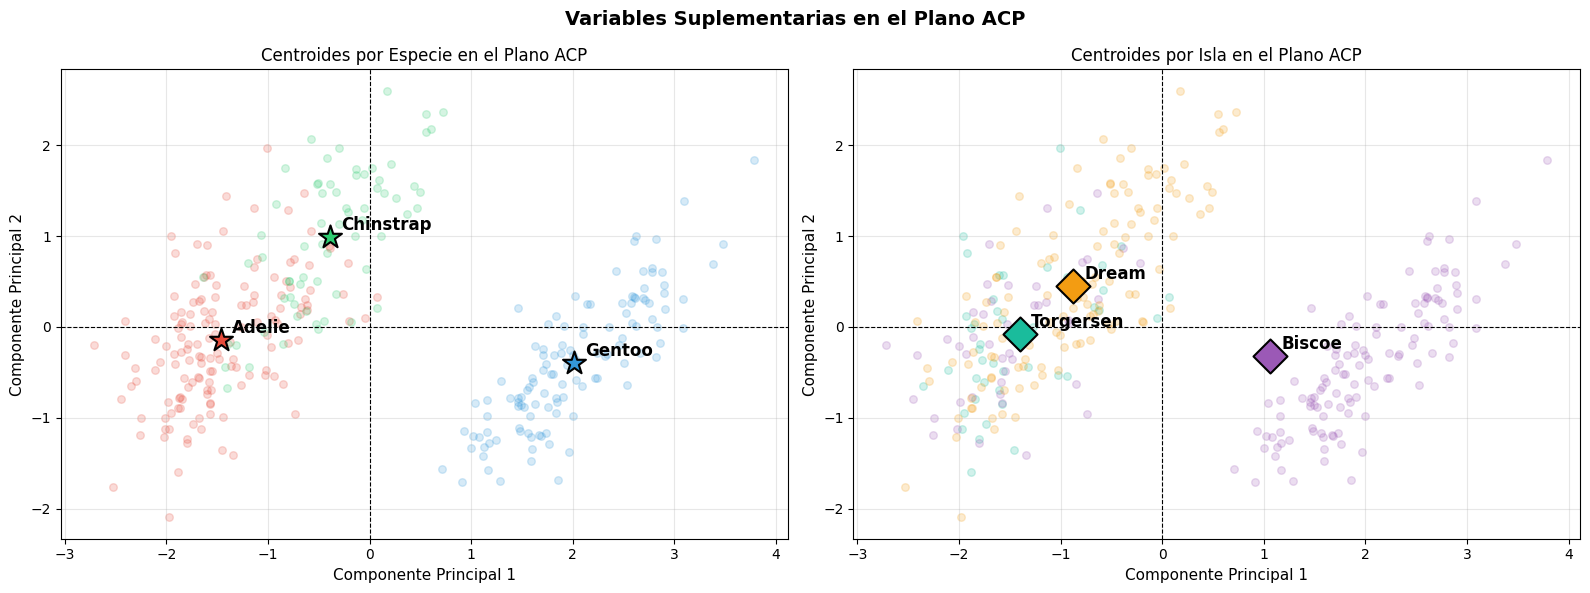

In [25]:
# Gráfico con centroides de especie e isla
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel izquierdo: centroides por ESPECIE ---
ax = axes[0]
colores_especie = {'Adelie': '#E74C3C', 'Chinstrap': '#2ECC71', 'Gentoo': '#3498DB'}
for especie in species.unique():
    mask = (species == especie)
    ax.scatter(
        resultados_pca.loc[mask, 'Componente 1'],
        resultados_pca.loc[mask, 'Componente 2'],
        color=colores_especie[especie], alpha=0.2, s=30
    )
for especie, row in centroides_especie.iterrows():
    ax.scatter(row['Componente 1'], row['Componente 2'],
               color=colores_especie[especie], s=300, marker='*',
               edgecolors='black', linewidths=1.5, zorder=5)
    ax.annotate(especie, (row['Componente 1'], row['Componente 2']),
                textcoords='offset points', xytext=(8, 5), fontsize=12, fontweight='bold')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Componente Principal 1', fontsize=11)
ax.set_ylabel('Componente Principal 2', fontsize=11)
ax.set_title('Centroides por Especie en el Plano ACP', fontsize=12)
ax.grid(alpha=0.3)

# --- Panel derecho: centroides por ISLA ---
ax = axes[1]
colores_isla = {'Biscoe': '#9B59B6', 'Dream': '#F39C12', 'Torgersen': '#1ABC9C'}
for isla in island.unique():
    mask = (island == isla)
    ax.scatter(
        resultados_pca.loc[mask, 'Componente 1'],
        resultados_pca.loc[mask, 'Componente 2'],
        color=colores_isla[isla], alpha=0.2, s=30
    )
for isla, row in centroides_isla.iterrows():
    ax.scatter(row['Componente 1'], row['Componente 2'],
               color=colores_isla[isla], s=300, marker='D',
               edgecolors='black', linewidths=1.5, zorder=5)
    ax.annotate(isla, (row['Componente 1'], row['Componente 2']),
                textcoords='offset points', xytext=(8, 5), fontsize=12, fontweight='bold')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Componente Principal 1', fontsize=11)
ax.set_ylabel('Componente Principal 2', fontsize=11)
ax.set_title('Centroides por Isla en el Plano ACP', fontsize=12)
ax.grid(alpha=0.3)

plt.suptitle('Variables Suplementarias en el Plano ACP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación de los centroides:**
> - **Centroides por especie:** El centroide de *Gentoo* se sitúa muy a la derecha en CP1 (mayor tamaño) y ligeramente por debajo en CP2. *Chinstrap* se posiciona hacia arriba en CP2 (mayor profundidad de pico relativa), mientras que *Adelie* queda en la zona izquierda-inferior. Los tres centroides están bien separados, confirmando que el ACP captura bien las diferencias entre especies.
> - **Centroides por isla:** *Biscoe* (donde viven principalmente *Gentoo*) se sitúa a la derecha, *Torgersen* (solo *Adelie*) a la izquierda-inferior, y *Dream* (mixta: *Adelie* y *Chinstrap*) en una posición intermedia ligeramente elevada en CP2.

---
# PARTE II: ANÁLISIS CLUSTER

Tras explorar las características físicas de los pingüinos mediante el Análisis
de Componentes Principales (ACP), ahora nos centraremos en evaluar la estructura de los grupos o clústeres existentes en el conjunto de datos. Utilizaremos técnicas de análisis de clúster, tanto jerárquicas como no jerárquicas, para identificar posibles agrupaciones basadas en las características (numéricas) de los pingüinos.

Para realizar el análisis de clustering, se deben satisfacer las siguientes condiciones:
- **Escala de las Variables**: Se cumple ya que trabajamos con la matriz de datos estandarizada para que no domine ninguna de las variables.
- **Ausencia de Valores Atípicos**: En el apartado anterior ya hemos verificado que no existía ningún dato atípico.
- **Tratamiento de Datos Perdidos**: También, previamente ya hemos verificado que no existen datos faltantes en el dataset.
- **Minimizar la correlación entre Variables**: Vamos a utilizar pocas vasriables numéricas, luego aunque algunas estén bastante realcionadas, también sirven para clasificar los grupos.

Estamos en disposición de comenzar el análisis.

## 1. Matriz de Distancias Euclídeas

In [26]:
# Calculamos la matriz de distancias euclídeas sobre los datos estandarizados
# (es importante trabajar con datos estandarizados para que ninguna variable domine)
# Empleamos la distancia euclídea, ya que es la que mejores propiedades matemáticas tiene
# y la más interpretativa para datos continuos en un espacio multidimensional
distance_matrix = distance.cdist(datos_estandarizados, datos_estandarizados, 'euclidean')
distance_df = pd.DataFrame(distance_matrix,
                            index=datos_estandarizados.index,
                            columns=datos_estandarizados.index)

# Mostramos la submatriz 8x8 de las primeras observaciones
print('Submatriz de distancias euclídeas (primeras 8 observaciones):')
distance_df.iloc[:8, :8].round()

Submatriz de distancias euclídeas (primeras 8 observaciones):


,0,1,2,3,4,5,6,7
0,0.0,1.0,1.0,1.0,1.0,0.0,2.0,1.0
1,1.0,0.0,1.0,1.0,2.0,0.0,2.0,1.0
2,1.0,1.0,0.0,1.0,1.0,1.0,2.0,1.0
3,1.0,1.0,1.0,0.0,1.0,1.0,2.0,1.0
4,1.0,2.0,1.0,1.0,0.0,2.0,1.0,2.0
5,0.0,0.0,1.0,1.0,2.0,0.0,2.0,1.0
6,2.0,2.0,2.0,2.0,1.0,2.0,0.0,2.0
7,1.0,1.0,1.0,1.0,2.0,1.0,2.0,0.0


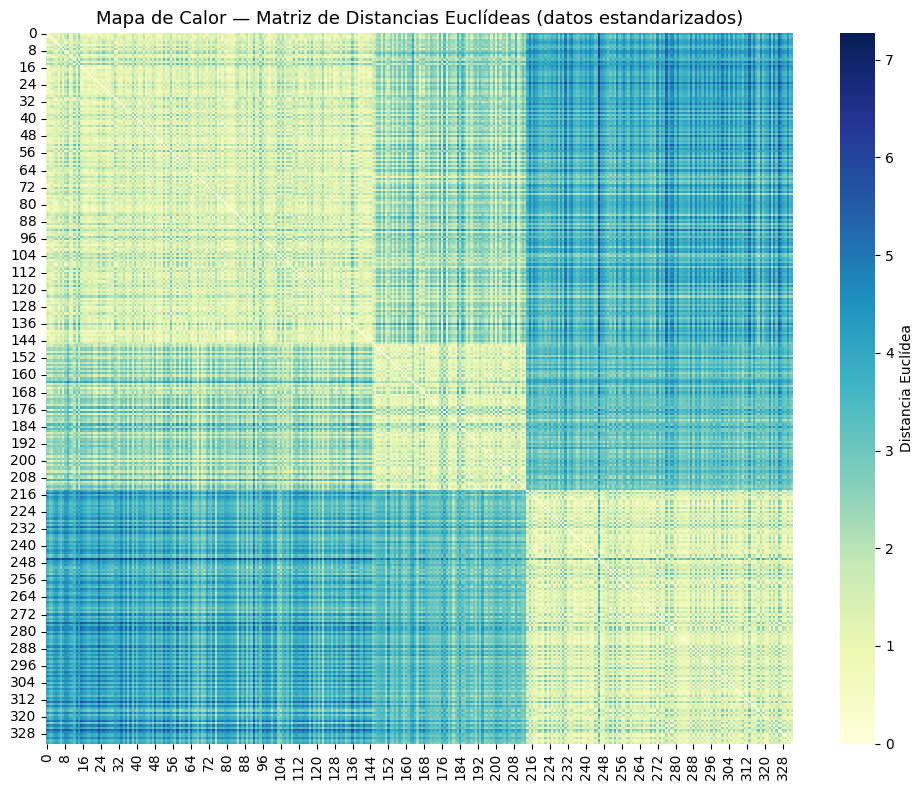

In [27]:
# Visualizamos la matriz de distancias completa con un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(distance_df, annot=False, cmap='YlGnBu',
            cbar_kws={'label': 'Distancia Euclídea'})
plt.title('Mapa de Calor — Matriz de Distancias Euclídeas (datos estandarizados)', fontsize=13)
plt.tight_layout()
plt.show()

> **Comentario:** El mapa de calor permite intuir la existencia de bloques de observaciones con distancias pequeñas entre sí (zonas azul oscuro), que corresponderán a los clusters. Se aprecian claramente tres grupos de observaciones similares, lo que justifica el análisis cluster.

## 2. Análisis Cluster Jerárquico — Determinación del Número Óptimo de Clusters

Una herramienta eficaz para identificar y visualizar patrones entre los diferentes elementos del conjunto de datos, son los mapas de calor que incorporan técnicas de reordenación basadas en la similitud. Estos métodos nos permiten agrupar los elementos más similares, es decir, aquellos con menor distancia entre sí, mejorando nuestra capacidad para detectar agrupaciones y relaciones clave en los datos.

El gráfico que presentaremos a continuación es un mapa de calor avanzado. Aplicaremos técnicas de clustering jerárquico para reordenar los datos de manera que los elementos similares se ubiquen cercanamente. Esta técnica realza la visualización, facilitando la identificación de grupos y patrones intrínsecos en los datos, crucial para una comprensión profunda y detallada del conjunto de datos analizado.

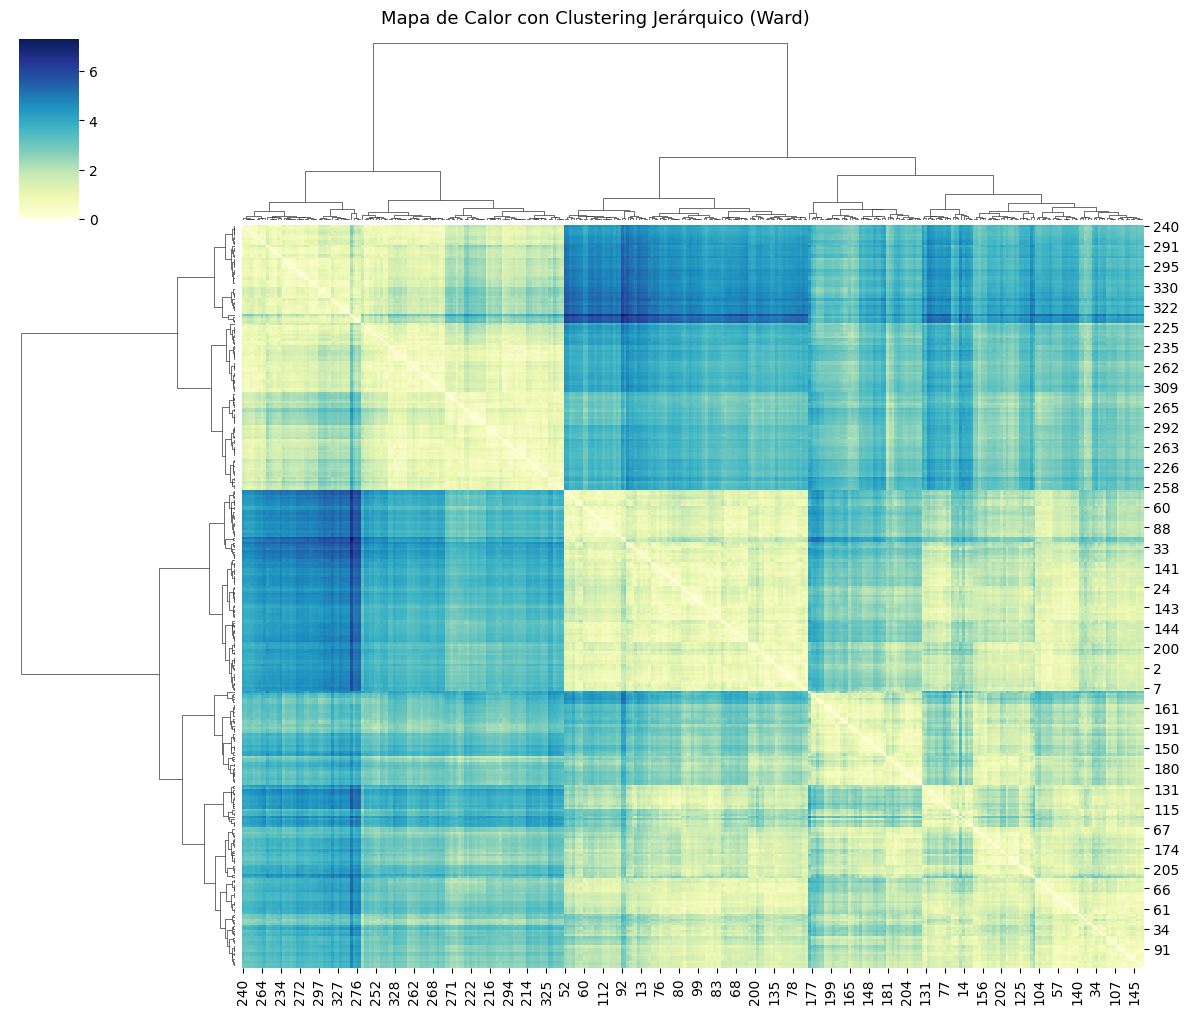

In [28]:
# Calculamos la matriz de enlace con el método de Ward sobre los datos estandarizados
linkage_matrix = sch.linkage(datos_estandarizados, method='ward')

# Mapa de calor avanzado con dendrograma (datos estandarizados)
g = sns.clustermap(distance_df, cmap='YlGnBu', fmt='.1f', annot=False,
                   method='ward', figsize=(12, 10))
plt.suptitle('Mapa de Calor con Clustering Jerárquico (Ward)', y=1.01, fontsize=13)
plt.show()

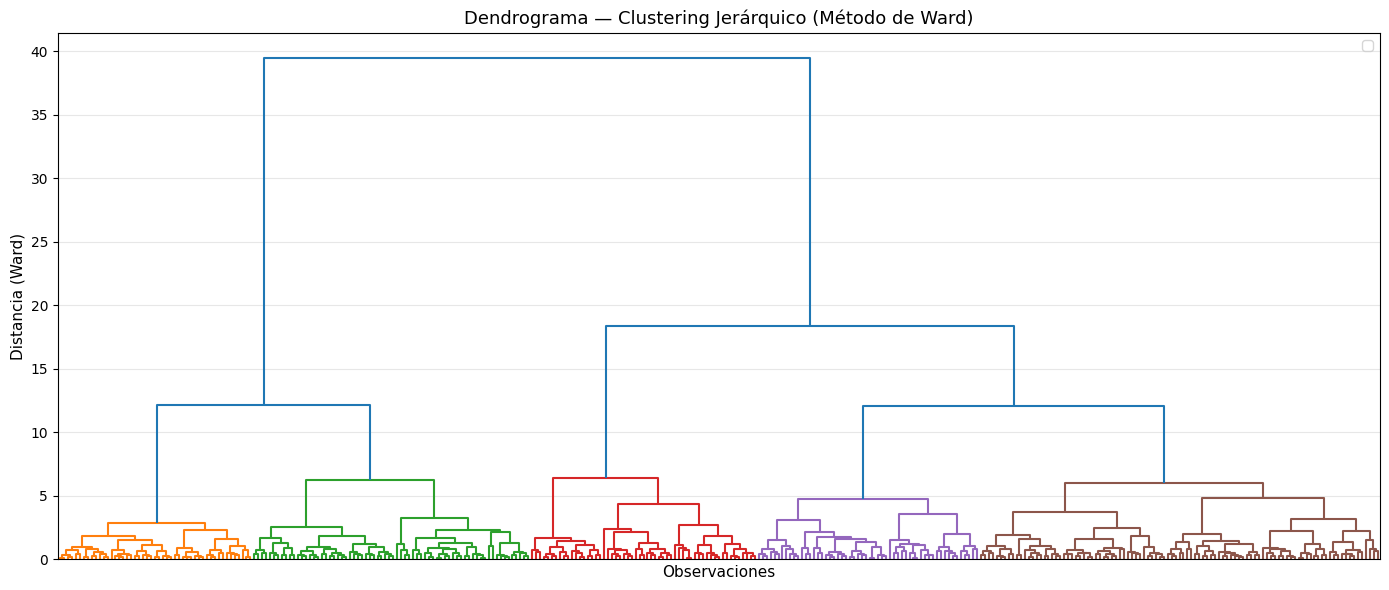

In [29]:
# Dendrograma independiente con umbral de color
color_threshold = 9

plt.figure(figsize=(14, 6))
dendrogram = sch.dendrogram(
    linkage_matrix,
    leaf_rotation=90,
    color_threshold=color_threshold,
    no_labels=True   # con 333 obs las etiquetas se solapan
)
# plt.axhline(y=color_threshold, color='red', linestyle='--', linewidth=1.5,
#            label=f'Corte sugerido (h={color_threshold})')
plt.title('Dendrograma — Clustering Jerárquico (Método de Ward)', fontsize=13)
plt.xlabel('Observaciones', fontsize=11)
plt.ylabel('Distancia (Ward)', fontsize=11)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **Interpretación del dendrograma:** En el dendrograma, los diferentes colores representan distintos conglomerados o grupos identificados por el algoritmo de agrupamiento jerárquico, utilizando el método de Ward (minimización de la variabilidad en un mismo cluster). Cada color indica un grupo distinto, de modo que los puntos con el mismo color pertenecen al mismo grupo. La jerarquía del dendrograma se forma al fusionar progresivamente grupos más pequeños en otros más grandes, revelando así la estructura de agrupamiento subyacente.

> - El dendrograma muestra claramente **3 grupos principales**: existe un salto considerable en la distancia de fusión cuando se pasa de 3 a 2 clusters, mientras que la fusión de los 3 primeros clusters ocurre a distancias relativamente pequeñas.
> - La línea de corte horizontal roja sugiere **k = 3 clusters**, coincidiendo con el número real de especies de pingüinos.
> - Esta elección se valida a continuación con el método del codo y el coeficiente de silueta.

In [30]:
# Asignamos provisionalmente las observaciones a 3 clusters (según análisis jerárquico)
cluster_jerarquico = fcluster(linkage_matrix, 3, criterion='maxclust')
print('Distribución de observaciones por cluster (jerárquico):')
pd.Series(cluster_jerarquico).value_counts().sort_index()

Distribución de observaciones por cluster (jerárquico):


1    119
2     57
3    157
Name: count, dtype: int64

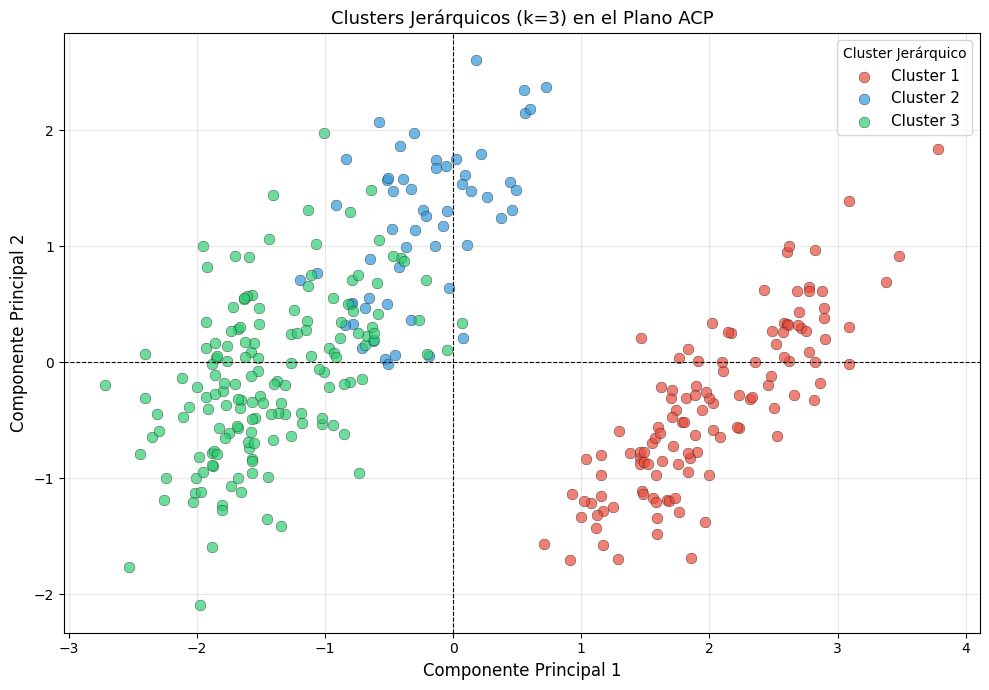

In [31]:
# Visualización de los clusters jerárquicos en el espacio ACP 2D
colores_cluster = {1: '#E74C3C', 2: '#3498DB', 3: '#2ECC71'}

fig, ax = plt.subplots(figsize=(10, 7))
for cluster_id in np.unique(cluster_jerarquico):
    mask = (cluster_jerarquico == cluster_id)
    ax.scatter(
        resultados_pca.loc[mask, 'Componente 1'],
        resultados_pca.loc[mask, 'Componente 2'],
        label=f'Cluster {cluster_id}',
        color=colores_cluster[cluster_id],
        alpha=0.7, s=60, edgecolors='black', linewidths=0.3
    )

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Componente Principal 1', fontsize=12)
ax.set_ylabel('Componente Principal 2', fontsize=12)
ax.set_title('Clusters Jerárquicos (k=3) en el Plano ACP', fontsize=13)
ax.legend(title='Cluster Jerárquico', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Una vez finalizado el análisis jerárquico, el siguiente paso es determinar el número más adecuado de clusters para nuestro conjunto de datos. Este número se contrastará con la propuesta obtenida del análisis jerárquico, que en nuestro caso sugiere 4 grupos o clusters.

Para este fin, aplicaremos diversos métodos, comenzando con el conocido método del codo:

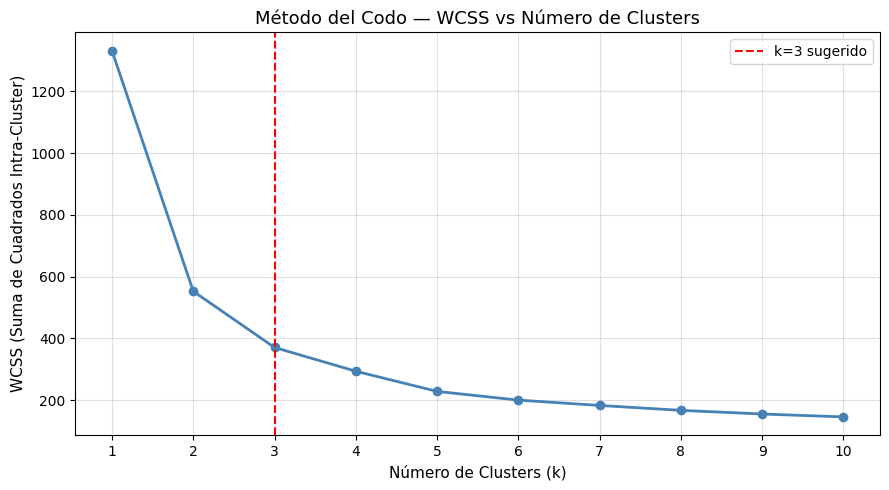

In [32]:
# Método del Codo — WCSS para k = 1 a 10
wcss = []
for k in range(1, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(datos_estandarizados)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='steelblue', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='k=3 sugerido')
plt.title('Método del Codo — WCSS vs Número de Clusters', fontsize=13)
plt.xlabel('Número de Clusters (k)', fontsize=11)
plt.ylabel('WCSS (Suma de Cuadrados Intra-Cluster)', fontsize=11)
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Observando el gráfico del método del codo, identificamos que el WCSS deja de reducirse significativamente a partir de 
$k=3$. Esta observación coincide con nuestro análisis previo de clustering jerárquico, reafirmando que un quinto cluster no aportaría una mejora sustancial.

Posteriormente, empleamos el método de la silueta para validar aún más nuestra elección del número óptimo de clusters. Este método evalúa la cohesión y separación de los clusters para diferentes valores de $K$ y el gráfico resultante nos proporcionará una visualización clara del puntaje de silueta promedio para cada valor de $K$, lo que nos ayudará a seleccionar el número de clusters que ofrece el mejor equilibrio.

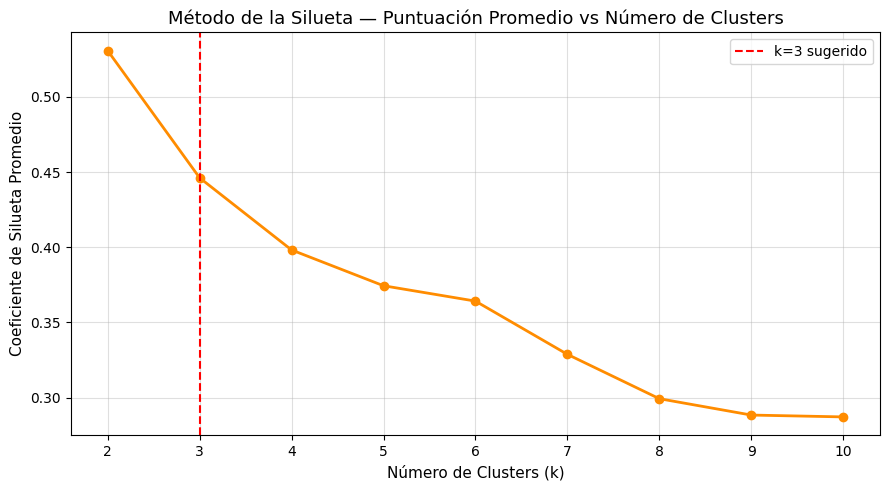

k=2: silueta media = 0.5308
k=3: silueta media = 0.4462
k=4: silueta media = 0.3982
k=5: silueta media = 0.3744
k=6: silueta media = 0.3642
k=7: silueta media = 0.3287
k=8: silueta media = 0.2992
k=9: silueta media = 0.2884
k=10: silueta media = 0.2871


In [33]:
# Método de la Silueta — score promedio para k = 2 a 10
silhouette_scores = []
for k in range(2, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(datos_estandarizados)
    score = silhouette_score(datos_estandarizados, kmeans_temp.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-',
         color='darkorange', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='k=3 sugerido')
plt.title('Método de la Silueta — Puntuación Promedio vs Número de Clusters', fontsize=13)
plt.xlabel('Número de Clusters (k)', fontsize=11)
plt.ylabel('Coeficiente de Silueta Promedio', fontsize=11)
plt.xticks(range(2, 11))
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

for k, s in zip(range(2, 11), silhouette_scores):
    print(f'k={k}: silueta media = {s:.4f}')

En nuestro caso, el método sugiere $k=2$ clusters como una solución óptima, pero considerando que esta elección podría ser demasiado simplista, el siguiente máximo local razonable es 3. Esto concuerda con el número de clusters que hemos estado considerando a lo largo de nuestro análisis.

## 3. Análisis Cluster No Jerárquico — K-Means

> **Decisión final sobre el número de clusters:**
> - El **método del codo** muestra un codo pronunciado en k=3.
> - El **método de la silueta** alcanza su valor máximo en k=2, pero el siguiente pico local corresponde a k=3.
> - El **análisis jerárquico** también sugería 3 clusters.
> - Dado que el dataset contiene 3 especies de pingüinos, **k = 3** es la elección más interpretable y coherente.

In [34]:
# K-Means con k=3 clusters
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(datos_estandarizados)

kmeans_labels = kmeans.labels_
print('Distribución de observaciones por cluster (K-Means, k=3):')
pd.Series(kmeans_labels).value_counts().sort_index()

Distribución de observaciones por cluster (K-Means, k=3):


0    129
1    119
2     85
Name: count, dtype: int64

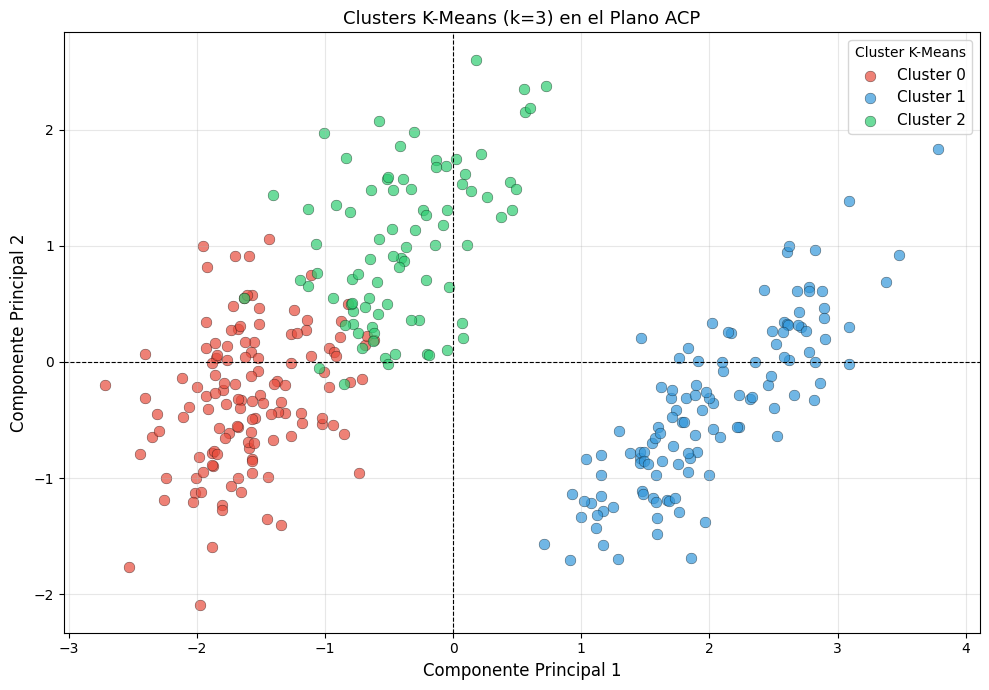

In [35]:
# Visualización de los clusters en el espacio ACP 2D
colores_cluster = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71'}

fig, ax = plt.subplots(figsize=(10, 7))
for cluster_id in np.unique(kmeans_labels):
    mask = (kmeans_labels == cluster_id)
    ax.scatter(
        resultados_pca.loc[mask, 'Componente 1'],
        resultados_pca.loc[mask, 'Componente 2'],
        label=f'Cluster {cluster_id}',
        color=colores_cluster[cluster_id],
        alpha=0.7, s=60, edgecolors='black', linewidths=0.3
    )

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Componente Principal 1', fontsize=12)
ax.set_ylabel('Componente Principal 2', fontsize=12)
ax.set_title('Clusters K-Means (k=3) en el Plano ACP', fontsize=13)
ax.legend(title='Cluster K-Means', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Evaluación de la Calidad de las Agrupaciones — Índice de Silueta

In [36]:
# Silueta global
silhouette_avg = silhouette_score(datos_estandarizados, kmeans_labels)
print(f'Coeficiente de Silueta Promedio (k=3): {silhouette_avg:.4f}')
print('(Valores próximos a +1 indican clusters bien separados y compactos)')

Coeficiente de Silueta Promedio (k=3): 0.4462
(Valores próximos a +1 indican clusters bien separados y compactos)


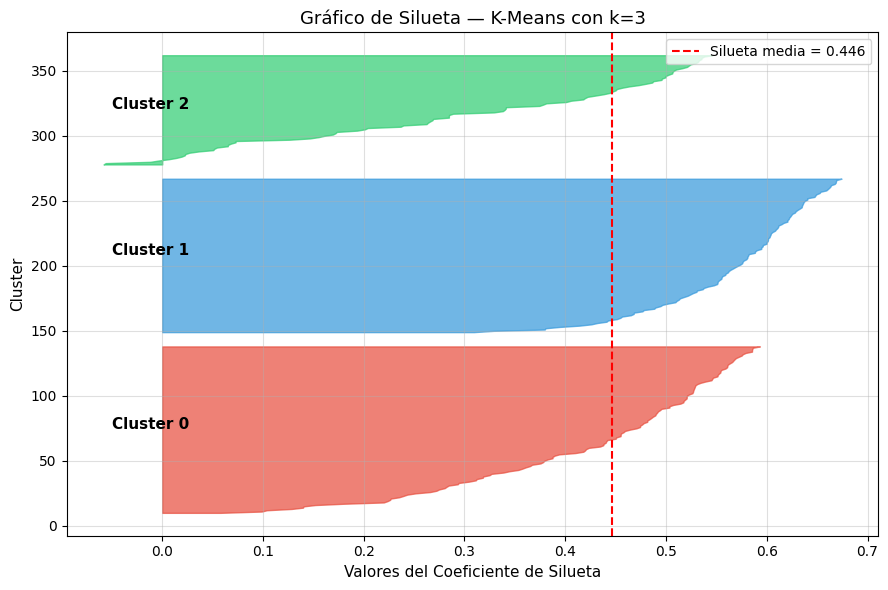

In [37]:
# Gráfico de Silueta detallado por observación y cluster
silhouette_vals = silhouette_samples(datos_estandarizados, kmeans_labels)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
colores_sil = ['#E74C3C', '#3498DB', '#2ECC71']

for i in range(k):
    ith_vals = silhouette_vals[kmeans_labels == i]
    ith_vals.sort()
    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i
    color = colores_sil[i]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, f'Cluster {i}', fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color='red', linestyle='--', linewidth=1.5,
           label=f'Silueta media = {silhouette_avg:.3f}')
ax.set_xlabel('Valores del Coeficiente de Silueta', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
ax.set_title('Gráfico de Silueta — K-Means con k=3', fontsize=13)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

> **Interpretación del gráfico de silueta:**
> - Un coeficiente de silueta promedio superior a 0.5 indica una estructura de agrupamiento razonable. El valor obtenido (0.45) confirma que los 3 clusters son coherentes.
> - La mayoría de las observaciones tienen valores de silueta positivos, lo que indica que están correctamente asignadas a su cluster.
> - El único cluster con observaciones 'mal' clasificadas es el cluster 2, al presentar observaciones con siluetas negativas.
> - Las barras en el cluster 1 (azul) son las más alargadas ya que son las que mejor clasifica al ser el grupo más separado y con una frontera definida.
> - Las observaciones con silueta negativa, cercana a 0 o más cortas (rojas y verdes) corresponden a pingüinos en la frontera entre clusters (principalmente entre *Adelie* y *Chinstrap*, que comparten características similares en algunas variables).

## 5. Caracterización de los Clusters

In [38]:
# Añadimos las etiquetas de cluster al DataFrame original
datos_cluster = datos.copy()
datos_cluster['Cluster']  = kmeans_labels
datos_cluster['species']  = species.values
datos_cluster['island']   = island.values

# Estadísticos descriptivos por cluster (variables originales)
print('=== ESTADÍSTICOS DESCRIPTIVOS POR CLUSTER (variables originales) ===')
resumen = datos_cluster.groupby('Cluster')[variables].agg(['mean', 'median', 'std']).round(2)
resumen

=== ESTADÍSTICOS DESCRIPTIVOS POR CLUSTER (variables originales) ===


bill_length_mm              bill_depth_mm               \
                  mean median   std          mean median   std   
Cluster                                                          
0                38.28   38.3  2.26         18.12   18.1  1.16   
1                47.57   47.4  3.11         15.00   15.0  0.99   
2                47.66   47.5  3.87         18.75   18.8  1.14   

        flipper_length_mm              body_mass_g                  
                     mean median   std        mean  median     std  
Cluster                                                             
0                  188.63  189.0  5.72     3593.80  3550.0  407.49  
1                  217.24  216.0  6.59     5092.44  5050.0  501.48  
2                  196.92  197.0  6.35     3898.24  3900.0  414.41

In [39]:
# Tabla de medias por cluster (más legible)
medias_cluster = datos_cluster.groupby('Cluster')[variables].mean().round(2)
print('Medias de las variables originales por Cluster:')
medias_cluster

Medias de las variables originales por Cluster:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Cluster,,,,
0,38.28,18.12,188.63,3593.80
1,47.57,15.00,217.24,5092.44
2,47.66,18.75,196.92,3898.24


In [40]:
# Composición de especies por cluster
print('Composición de especies por cluster:')
composicion = pd.crosstab(datos_cluster['Cluster'], datos_cluster['species'])
composicion

Composición de especies por cluster:


species,Adelie,Chinstrap,Gentoo
Cluster,,,
0,124,5,0
1,0,0,119
2,22,63,0


In [41]:
# Composición de islas por cluster
print('Composición de islas por cluster:')
pd.crosstab(datos_cluster['Cluster'], datos_cluster['island'])

Composición de islas por cluster:


island,Biscoe,Dream,Torgersen
Cluster,,,
0,37,54,38
1,119,0,0
2,7,69,9


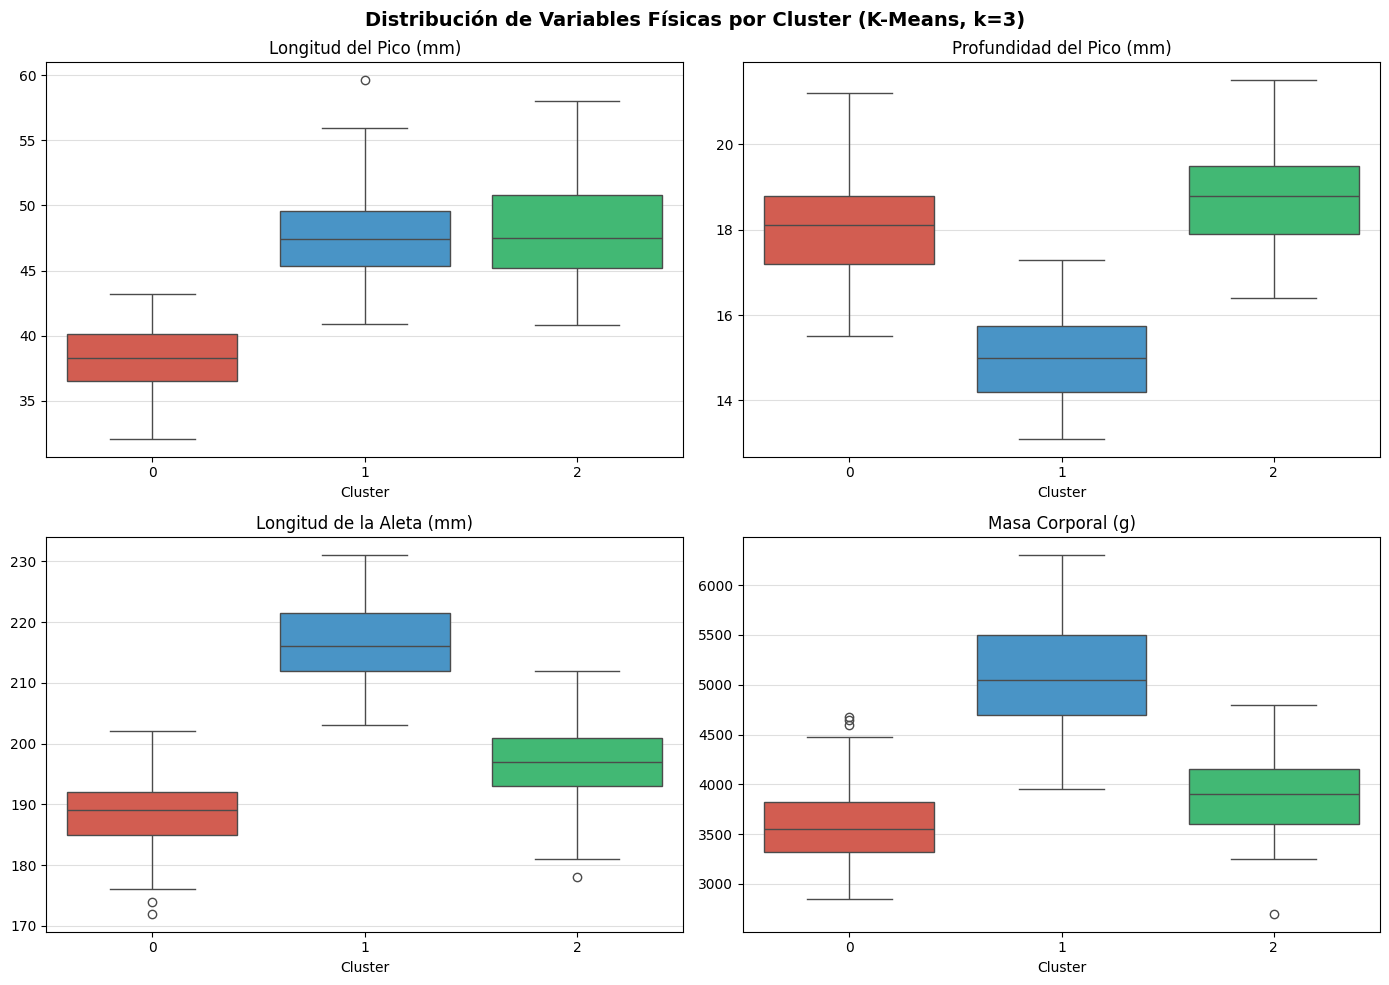

In [43]:
# Boxplots por cluster para cada variable física
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
nombres_variables = {
    'bill_length_mm'   : 'Longitud del Pico (mm)',
    'bill_depth_mm'    : 'Profundidad del Pico (mm)',
    'flipper_length_mm': 'Longitud de la Aleta (mm)',
    'body_mass_g'      : 'Masa Corporal (g)'
}

palette_clusters = {'0': '#E74C3C', '1': '#3498DB', '2': '#2ECC71'}

for ax, var in zip(axes.flatten(), variables):
    sns.boxplot(
        data=datos_cluster, x='Cluster', y=var,
        palette=palette_clusters, ax=ax,
        order=[0, 1, 2]
    )
    ax.set_title(nombres_variables[var], fontsize=12)
    ax.set_xlabel('Cluster', fontsize=10)
    ax.set_ylabel('')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Distribución de Variables Físicas por Cluster (K-Means, k=3)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

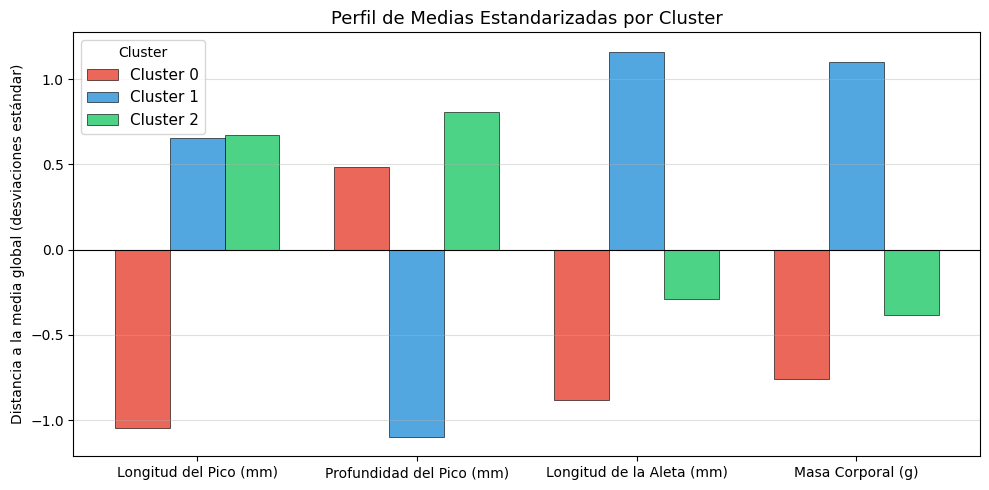

In [44]:
# Perfil de medias normalizadas por cluster (gráfico de radar / barras agrupadas)
medias_norm = (medias_cluster - datos[variables].mean()) / datos[variables].std()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(variables))
width = 0.25

for idx, cluster_id in enumerate([0, 1, 2]):
    bars = ax.bar(x + idx * width - width, medias_norm.loc[cluster_id],
                  width, label=f'Cluster {cluster_id}',
                  color=list(palette_clusters.values())[idx],
                  edgecolor='black', linewidth=0.5, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([nombres_variables[v] for v in variables], fontsize=10)
ax.set_ylabel('Distancia a la media global (desviaciones estándar)', fontsize=10)
ax.set_title('Perfil de Medias Estandarizadas por Cluster', fontsize=13)
ax.legend(title='Cluster', fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [46]:
print(medias_norm)

         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
Cluster                                                               
0             -1.044641       0.485028          -0.880221    -0.761606
1              0.654128      -1.099343           1.161052     1.099560
2              0.670585       0.804950          -0.288744    -0.383521


> **Caracterización final de los clusters:**
>
> | Cluster | Especie predominante | Descripción |
> |---------|---------------------|-------------|
> | **0**   | *Adelie*   | Pingüinos **pequeños con pico profundo y corto**. Masa corporal y longitud de aleta por debajo de la media global. Profundidad del pico muy superior a la media. Presentes principalmente en Torgersen y Dream. |
> | **1**   | *Gentoo*   | Pingüinos **más grandes en todos los aspectos**: mayor masa corporal, aletas más largas y pico más largo. Profundidad del pico por debajo de la media. Exclusivos de la isla Biscoe. |
> | **2**   | *Chinstrap* | Pingüinos de **tamaño intermedio con pico largo y profundo**. Longitud de pico claramente superior a la media; profundidad también elevada. Localizados en Dream. |
>
> La separación entre clusters es muy nítida, especialmente entre *Gentoo* y el resto. Los clusters corresponden casi perfectamente a las tres especies reales del dataset, validando la calidad del análisis.

---
## Resumen Ejecutivo

### ACP
- La matriz de correlaciones muestra que `flipper_length_mm` y `body_mass_g` están fuertemente correlacionadas entre sí, al igual que `bill_length_mm` con ambas. `bill_depth_mm` correlaciona negativamente con todas las demás.
- Con **2 componentes principales** se retiene el **~88% de la variabilidad** total, siendo suficiente para una representación eficiente.
- **CP1** es un índice de **tamaño corporal general** (carga positiva alta en aleta, masa y longitud de pico). **CP2** captura la **forma del pico** (profundidad vs. longitud).
- *Gentoo* destaca en CP1 (mayor tamaño); *Chinstrap* destaca en CP2 (pico más profundo relativo).

### Análisis Cluster
- El dendrograma jerárquico (Ward), el método del codo y la silueta convergen en **k = 3 clusters**.
- El coeficiente de silueta promedio (0.45) indica agrupaciones razonablemente buenas.
- Los 3 clusters corresponden casi exactamente a las 3 especies de pingüinos: **Cluster 0 → Adelie**, **Cluster 1 → Gentoo**, **Cluster 2 → Chinstrap**.
- *Gentoo* es la especie más diferenciada (mayor tamaño); *Adelie* y *Chinstrap* son más similares entre sí pero distinguibles por la morfología del pico.